In [1]:
import os
import sys
sys.path.append('../../')
import utils.funciones as fns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
from tabulate import tabulate
import matplotlib.colors as mcolors
fns.formato_graficas()

## MSE - Validation - 400 years

In [ ]:
planet_colors = ["#FFFFFF", "#00FFFF", "#FF00FF", "#39FF14", "#FF4500", "#FFD700", "#E6A8FF", "#00FF90", "#1E90FF", "#FF9999"]

func_group = [
    r'$\log(\cosh(x))$', 
    r'$\log_{1p}(x\tanh(x))$', 
    r'$\sqrt{x^2+1}-1$', 
    r'$\tanh(x)$', 
    r'$x\tanh(x)$'
]

file_mapping = {
    r'$\log(\cosh(x))$': 'log(cosh(x))',
    r'$\log_{1p}(x\tanh(x))$': 'log1p(xtanh(x))',
    r'$\sqrt{x^2+1}-1$': 'sqrt(x^2+1)-1',
    r'$\tanh(x)$': 'tanh(x)',
    r'$x\tanh(x)$': 'xtanh(x)'
}

# LOAD

In [ ]:
for fc in func_group:
    folder_name = file_mapping[fc]
    globals()[f'H_{folder_name}'] = np.load(f"../../results analysis/stability analysis/dt_0.0005/Total_Energy_{folder_name}.npz")["H"]

H_True = np.load(f"../../results analysis/stability analysis/True/Total_Energy.npz")["H"]

# Graph

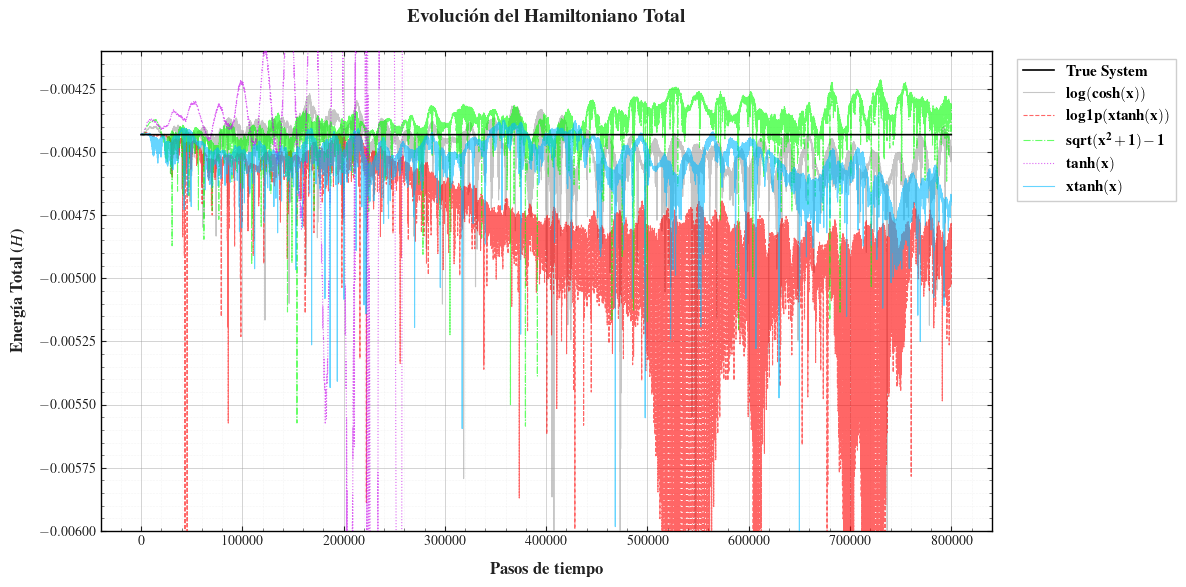

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

line_styles = ['-', '--', '-.', ':']

H_True = np.load("../../results analysis/stability analysis/True/Total_Energy.npz")["H"]
H_True_half = H_True[:len(H_True)//2]
ax.plot(H_True_half, label=r"$\mathbf{True\ System}$", linewidth=1.2, color='#000000', linestyle='-', zorder=5)

for i, fc in enumerate(func_group):
    folder_name = file_mapping[fc]
    H_data = globals()[f'H_{folder_name}']
    
    color_idx = i % len(planet_colors)
    style_idx = i % len(line_styles)
    
    base_color = planet_colors[color_idx]
    ls = line_styles[style_idx]
    
    if color_idx == 0:
        inv_color = "#A0A0A0"
    else:
        rgb = mcolors.to_rgb(base_color)
        inv_color = (1.0 - rgb[0], 1.0 - rgb[1], 1.0 - rgb[2])
        
    latex_name = folder_name.replace(' ', r'\ ')
    
    H_data_half = H_data[:len(H_data)//2]
    
    ax.plot(H_data_half, label=fr"$\mathbf{{{latex_name}}}$", linewidth=0.8, color=inv_color, linestyle=ls, alpha=0.6, zorder=3)

ax.set_title(r"\textbf{Evolución del Hamiltoniano Total}", fontsize=14, pad=20, color='#222222')
ax.set_xlabel(r"\textbf{Pasos de tiempo}", fontsize=12, labelpad=10, color='#222222')
ax.set_ylabel(r"\textbf{Energía Total ($H$)}", fontsize=12, labelpad=10, color='#222222')

ax.tick_params(axis='both', which='major', labelsize=10, colors='#222222', zorder=4)
ax.tick_params(axis='both', which='minor', colors='#666666', labelsize=0, zorder=4)
ax.minorticks_on()

ax.grid(True, which='major', color='#999999', linestyle='-', linewidth=0.6, alpha=0.5, zorder=1)
ax.grid(True, which='minor', color='#cccccc', linestyle=':', linewidth=0.4, alpha=0.4, zorder=1)

ax.set_ylim([-0.006, -0.0041])

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, 
          frameon=True, edgecolor='#cccccc', facecolor='#ffffff', framealpha=0.95)

plt.tight_layout()
plt.show()
plt.close(fig)

In [42]:
table_data_max = []
table_data_min = []

mid_true = len(H_True) // 2
max_true = np.max(H_True[:mid_true])
min_true = np.min(H_True[:mid_true])

table_data_max.append(["True System", max_true])
table_data_min.append(["True System", min_true])

for fc in func_group:
    if fc == 'tanh(x)' or file_mapping[fc] == 'tanh(x)':
        continue
        
    folder_name = file_mapping[fc]
    H_data = globals()[f'H_{folder_name}']
    
    mid_idx = len(H_data) // 2
    max_val = np.max(H_data[:mid_idx])
    min_val = np.min(H_data[:mid_idx])
    
    table_data_max.append([folder_name, max_val])
    table_data_min.append([folder_name, min_val])

print(tabulate(table_data_max, headers=["Modelo / Función", "Max Hamiltoniano (1ra Mitad)"], tablefmt="fancy_grid", floatfmt=".4e"))
print("\n")
print(tabulate(table_data_min, headers=["Modelo / Función", "Min Hamiltoniano (1ra Mitad)"], tablefmt="fancy_grid", floatfmt=".4e"))

╒════════════════════╤════════════════════════════════╕
│ Modelo / Función   │   Max Hamiltoniano (1ra Mitad) │
╞════════════════════╪════════════════════════════════╡
│ True System        │                    -4.4315e-03 │
├────────────────────┼────────────────────────────────┤
│ log(cosh(x))       │                    -4.2690e-03 │
├────────────────────┼────────────────────────────────┤
│ log1p(xtanh(x))    │                    -4.4210e-03 │
├────────────────────┼────────────────────────────────┤
│ sqrt(x^2+1)-1      │                    -4.2139e-03 │
├────────────────────┼────────────────────────────────┤
│ xtanh(x)           │                    -4.3728e-03 │
╘════════════════════╧════════════════════════════════╛


╒════════════════════╤════════════════════════════════╕
│ Modelo / Función   │   Min Hamiltoniano (1ra Mitad) │
╞════════════════════╪════════════════════════════════╡
│ True System        │                    -4.4315e-03 │
├────────────────────┼────────────────────────